# Baseline Link Prediction on Social Networks

In this notebook, I evaluate classical link prediction baselines for recovering missing edges in real-world social networks.

To create a controlled evaluation setting, I simulate missing relational data by randomly removing a subset of true edges from each observed graph. Because the removed edges are known, I can evaluate how accurately each baseline method reconstructs the original network structure.

The baseline methods used here are:

- Common Neighbors
- Adamic-Adar
- Jaccard

These methods rely only on local network structure and provide a useful comparison point for the embedding-based and reinforcement-learning models developed later in the project.

In [3]:
import random
import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import urllib.request
import gzip
import shutil

random.seed(42)
np.random.seed(42)

In [4]:
def common_neighbors_score(G, u, v):
    return len(list(nx.common_neighbors(G, u, v)))

def adamic_adar_score(G, u, v):
    score = 0.0
    for w in nx.common_neighbors(G, u, v):
        deg_w = G.degree(w)
        if deg_w > 1:
            score += 1 / math.log(deg_w)
    return score

def jaccard_score(G, u, v):
    neighbors_u = set(G.neighbors(u))
    neighbors_v = set(G.neighbors(v))
    union_size = len(neighbors_u.union(neighbors_v))
    if union_size == 0:
        return 0.0
    return len(neighbors_u.intersection(neighbors_v)) / union_size

In [13]:
def evaluate_link_prediction(
    G,
    dataset_name,
    remove_fraction=0.10,
    n_trials=1,
    max_non_edges=None,
    verbose=True
):
    """
    Evaluate classical link prediction baselines on one graph.

    Parameters
    ----------
    G : networkx.Graph
        Input graph.
    dataset_name : str
        Name of dataset for printing/results.
    remove_fraction : float or list of float
        Fraction(s) of edges to remove for evaluation.
    n_trials : int
        Number of repeated random trials per removal fraction.
    max_non_edges : int or None
        Optional cap on candidate non-edges. Use None for full network.
    verbose : bool
        Whether to print progress.

    Returns
    -------
    dict or pd.DataFrame
        If one fraction and one trial are provided, returns a single dict.
        Otherwise returns a DataFrame with one row per trial.
    """

    # convert single fraction to list
    if not isinstance(remove_fraction, (list, tuple, np.ndarray)):
        fractions = [float(remove_fraction)]
    else:
        fractions = [float(f) for f in remove_fraction]

    all_rows = []

    for frac in fractions:
        for trial in range(1, n_trials + 1):

            if verbose:
                print(f"\n===== {dataset_name} ({int(frac * 100)}% removed, trial {trial}) =====")

            G_missing = G.copy()

            # remove a random subset of true edges
            edges = list(G_missing.edges())
            num_remove = int(len(edges) * frac)
            removed_edges = random.sample(edges, num_remove)
            G_missing.remove_edges_from(removed_edges)

            true_removed = set(tuple(sorted(edge)) for edge in removed_edges)

            if verbose:
                print("Original edges:", G.number_of_edges())
                print("Observed edges:", G_missing.number_of_edges())
                print("Removed edges:", len(removed_edges))

            # candidate non-edges
            non_edges = list(nx.non_edges(G_missing))
            if max_non_edges is not None:
                non_edges = non_edges[:max_non_edges]

            if verbose:
                print("Candidate non-edges considered:", len(non_edges))

            scores_cn = []
            scores_aa = []
            scores_jc = []

            for u, v in non_edges:
                cn = common_neighbors_score(G_missing, u, v)

                # skip disconnected candidates for efficiency
                if cn > 0:
                    aa = adamic_adar_score(G_missing, u, v)
                    jc = jaccard_score(G_missing, u, v)

                    scores_cn.append((u, v, cn))
                    scores_aa.append((u, v, aa))
                    scores_jc.append((u, v, jc))

            scores_cn = sorted(scores_cn, key=lambda x: x[2], reverse=True)
            scores_aa = sorted(scores_aa, key=lambda x: x[2], reverse=True)
            scores_jc = sorted(scores_jc, key=lambda x: x[2], reverse=True)

            k = len(removed_edges)

            predicted_cn = set(tuple(sorted((u, v))) for u, v, score in scores_cn[:k])
            predicted_aa = set(tuple(sorted((u, v))) for u, v, score in scores_aa[:k])
            predicted_jc = set(tuple(sorted((u, v))) for u, v, score in scores_jc[:k])

            correct_cn = true_removed.intersection(predicted_cn)
            correct_aa = true_removed.intersection(predicted_aa)
            correct_jc = true_removed.intersection(predicted_jc)

            recovery_cn = len(correct_cn) / len(true_removed)
            recovery_aa = len(correct_aa) / len(true_removed)
            recovery_jc = len(correct_jc) / len(true_removed)

            if verbose:
                print("Common Neighbors recovery rate:", recovery_cn)
                print("Adamic-Adar recovery rate:", recovery_aa)
                print("Jaccard recovery rate:", recovery_jc)

            all_rows.append({
                "dataset": dataset_name,
                "remove_fraction": frac,
                "trial": trial,
                "original_edges": G.number_of_edges(),
                "observed_edges": G_missing.number_of_edges(),
                "removed_edges": len(removed_edges),
                "candidate_non_edges": len(non_edges),
                "recovery_cn": recovery_cn,
                "recovery_aa": recovery_aa,
                "recovery_jc": recovery_jc
            })

    # if exactly one fraction and one trial, return dict for convenience
    if len(all_rows) == 1:
        return all_rows[0]

    return pd.DataFrame(all_rows)

## Dataset 1: Facebook Social Circles

I begin with the Facebook Social Circles network from the Stanford SNAP collection. In this dataset, nodes represent Facebook users and undirected edges represent friendship ties.

In [8]:
url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
urllib.request.urlretrieve(url, "facebook_combined.txt.gz")

with gzip.open("facebook_combined.txt.gz", "rb") as f_in:
    with open("facebook_edges.txt", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

edges_facebook = pd.read_csv(
    "facebook_edges.txt",
    sep=" ",
    header=None,
    names=["u", "v"]
)

G_facebook = nx.from_pandas_edgelist(edges_facebook, source="u", target="v")

print("Facebook nodes:", G_facebook.number_of_nodes())
print("Facebook edges:", G_facebook.number_of_edges())

Facebook nodes: 4039
Facebook edges: 88234


In [15]:
facebook_trials = evaluate_link_prediction(
    G_facebook,
    "Facebook Social Circles",
    remove_fraction=[0.05, 0.10, 0.15, 0.20],
    n_trials=5
)


===== Facebook Social Circles (5% removed, trial 1) =====
Original edges: 88234
Observed edges: 83823
Removed edges: 4411
Candidate non-edges considered: 8070918
Common Neighbors recovery rate: 0.23826796644751758
Adamic-Adar recovery rate: 0.2530038540013602
Jaccard recovery rate: 0.23350714123781455

===== Facebook Social Circles (5% removed, trial 2) =====
Original edges: 88234
Observed edges: 83823
Removed edges: 4411
Candidate non-edges considered: 8070918
Common Neighbors recovery rate: 0.230559963727046
Adamic-Adar recovery rate: 0.24416232146905464
Jaccard recovery rate: 0.22942643391521197

===== Facebook Social Circles (5% removed, trial 3) =====
Original edges: 88234
Observed edges: 83823
Removed edges: 4411
Candidate non-edges considered: 8070918
Common Neighbors recovery rate: 0.23554749489911583
Adamic-Adar recovery rate: 0.25073679437769214
Jaccard recovery rate: 0.23260031738834733

===== Facebook Social Circles (5% removed, trial 4) =====
Original edges: 88234
Observe

In [16]:
url = "https://snap.stanford.edu/data/ca-GrQc.txt.gz"
urllib.request.urlretrieve(url, "ca-GrQc.txt.gz")

with gzip.open("ca-GrQc.txt.gz", "rb") as f_in:
    with open("arxiv_edges.txt", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

edges_arxiv = pd.read_csv(
    "arxiv_edges.txt",
    sep="\t",
    comment="#",
    header=None,
    names=["u", "v"]
)

G_arxiv = nx.from_pandas_edgelist(edges_arxiv, source="u", target="v")

print("ArXiv nodes:", G_arxiv.number_of_nodes())
print("ArXiv edges:", G_arxiv.number_of_edges())

ArXiv nodes: 5242
ArXiv edges: 14496


In [17]:
arxiv_trials = evaluate_link_prediction(
    G_arxiv,
    "ArXiv GR-QC Collaboration Network",
    remove_fraction=[0.05, 0.10, 0.15, 0.20],
    n_trials=5
)


===== ArXiv GR-QC Collaboration Network (5% removed, trial 1) =====
Original edges: 14496
Observed edges: 13772
Removed edges: 724
Candidate non-edges considered: 13722901
Common Neighbors recovery rate: 0.31629834254143646
Adamic-Adar recovery rate: 0.4212707182320442
Jaccard recovery rate: 0.29972375690607733

===== ArXiv GR-QC Collaboration Network (5% removed, trial 2) =====
Original edges: 14496
Observed edges: 13772
Removed edges: 724
Candidate non-edges considered: 13722901
Common Neighbors recovery rate: 0.32044198895027626
Adamic-Adar recovery rate: 0.44613259668508287
Jaccard recovery rate: 0.319060773480663

===== ArXiv GR-QC Collaboration Network (5% removed, trial 3) =====
Original edges: 14496
Observed edges: 13772
Removed edges: 724
Candidate non-edges considered: 13722900
Common Neighbors recovery rate: 0.2900552486187845
Adamic-Adar recovery rate: 0.4005524861878453
Jaccard recovery rate: 0.29972375690607733

===== ArXiv GR-QC Collaboration Network (5% removed, trial 

In [18]:
url = "https://snap.stanford.edu/data/email-Eu-core.txt.gz"
urllib.request.urlretrieve(url, "email-Eu-core.txt.gz")

with gzip.open("email-Eu-core.txt.gz", "rb") as f_in:
    with open("email_edges.txt", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

edges_email = pd.read_csv(
    "email_edges.txt",
    sep=" ",
    header=None,
    names=["u", "v"]
)

G_email = nx.from_pandas_edgelist(edges_email, source="u", target="v")

print("Email nodes:", G_email.number_of_nodes())
print("Email edges:", G_email.number_of_edges())

Email nodes: 1005
Email edges: 16706


In [19]:
email_trials = evaluate_link_prediction(
    G_email,
    "Email Communication Network",
    remove_fraction=[0.05, 0.10, 0.15, 0.20],
    n_trials=5
)


===== Email Communication Network (5% removed, trial 1) =====
Original edges: 16706
Observed edges: 15871
Removed edges: 835
Candidate non-edges considered: 489250
Common Neighbors recovery rate: 0.13293413173652693
Adamic-Adar recovery rate: 0.14610778443113773
Jaccard recovery rate: 0.13892215568862276

===== Email Communication Network (5% removed, trial 2) =====
Original edges: 16706
Observed edges: 15871
Removed edges: 835
Candidate non-edges considered: 489235
Common Neighbors recovery rate: 0.1281437125748503
Adamic-Adar recovery rate: 0.14491017964071856
Jaccard recovery rate: 0.13293413173652693

===== Email Communication Network (5% removed, trial 3) =====
Original edges: 16706
Observed edges: 15871
Removed edges: 835
Candidate non-edges considered: 489247
Common Neighbors recovery rate: 0.14850299401197606
Adamic-Adar recovery rate: 0.16407185628742516
Jaccard recovery rate: 0.14251497005988023

===== Email Communication Network (5% removed, trial 4) =====
Original edges: 1

In [23]:
all_trials = pd.concat(
    [facebook_trials, arxiv_trials, email_trials],
    ignore_index=True
)

summary_table = (
    all_trials
    .groupby(["dataset", "remove_fraction"])
    .agg({
        "recovery_cn": ["mean", "std"],
        "recovery_aa": ["mean", "std"],
        "recovery_jc": ["mean", "std"]
    })
    .reset_index()
)

summary_table.columns = [
    "dataset",
    "remove_fraction",
    "cn_mean",
    "cn_std",
    "aa_mean",
    "aa_std",
    "jc_mean",
    "jc_std"
]

summary_table["remove_percent"] = summary_table["remove_fraction"] * 100

summary_table

,dataset,remove_fraction,cn_mean,cn_std,aa_mean,aa_std,jc_mean,jc_std,remove_percent
0,ArXiv GR-QC Collaboration Network,0.05,0.319890,0.020030,0.431768,0.021097,0.297790,0.014004,5.0
1,ArXiv GR-QC Collaboration Network,0.10,0.351001,0.008792,0.480883,0.005762,0.346998,0.005332,10.0
2,ArXiv GR-QC Collaboration Network,0.15,0.376357,0.009345,0.517847,0.010526,0.341306,0.010020,15.0
3,ArXiv GR-QC Collaboration Network,0.20,0.411659,0.014104,0.536668,0.009508,0.401794,0.008212,20.0
4,Email Communication Network,0.05,0.137485,0.009670,0.152335,0.008735,0.138443,0.004835,5.0
5,Email Communication Network,0.10,0.196407,0.008123,0.219760,0.009002,0.205030,0.002631,10.0
6,Email Communication Network,0.15,0.237844,0.005498,0.264511,0.003347,0.234012,0.008026,15.0
7,Email Communication Network,0.20,0.259623,0.009870,0.290153,0.011473,0.264831,0.005859,20.0
8,Facebook Social Circles,0.05,0.236046,0.004740,0.250011,0.004611,0.229971,0.003184,5.0
9,Facebook Social Circles,0.10,0.312524,0.004154,0.327666,0.003985,0.322589,0.002843,10.0


In [24]:
def plot_dataset_results(summary_df, dataset_name):
    df = summary_df[summary_df["dataset"] == dataset_name].copy()
    df = df.sort_values("remove_fraction")

    plt.figure(figsize=(7, 4))

    plt.errorbar(
        df["remove_percent"],
        df["cn_mean"],
        yerr=df["cn_std"],
        marker="o",
        capsize=4,
        label="Common Neighbors"
    )

    plt.errorbar(
        df["remove_percent"],
        df["aa_mean"],
        yerr=df["aa_std"],
        marker="o",
        capsize=4,
        label="Adamic-Adar"
    )

    plt.errorbar(
        df["remove_percent"],
        df["jc_mean"],
        yerr=df["jc_std"],
        marker="o",
        capsize=4,
        label="Jaccard"
    )


    plt.xlabel("Removed Edge Fraction (%)")
    plt.ylabel("Recovery Rate")
    plt.title(f"{dataset_name}: Baseline Recovery Across Missingness Levels")
    plt.ylim(0, 0.7)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [33]:
summary_table.to_csv("baseline_summary_table.csv", index=False)

In [34]:
from google.colab import files
files.download("baseline_summary_table.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

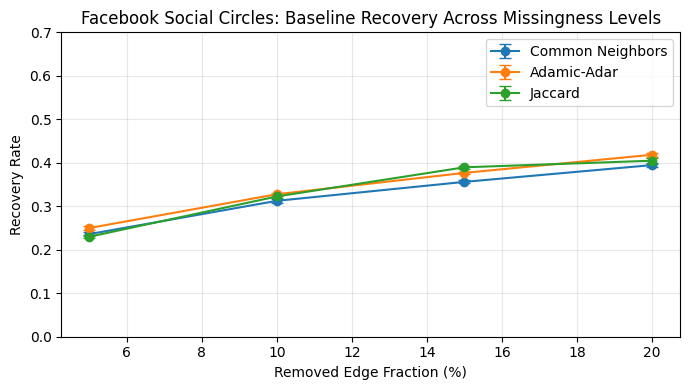

In [25]:
plot_dataset_results(summary_table, "Facebook Social Circles")

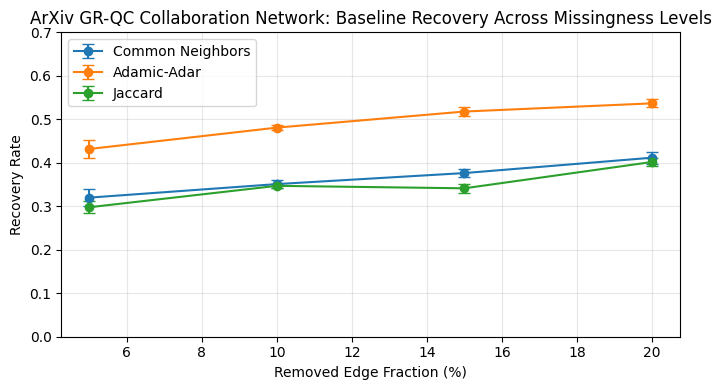

In [26]:
plot_dataset_results(summary_table, "ArXiv GR-QC Collaboration Network")

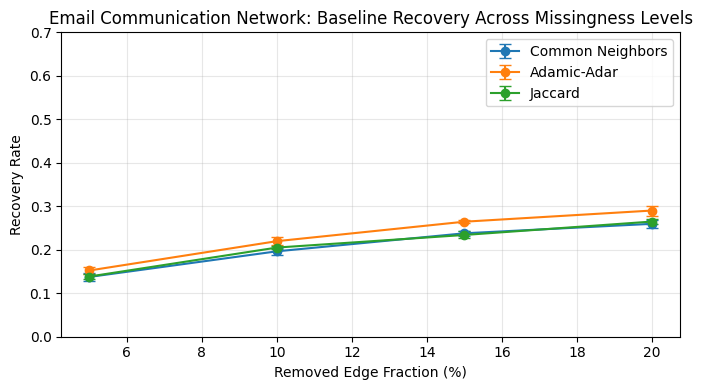

In [27]:
plot_dataset_results(summary_table, "Email Communication Network")

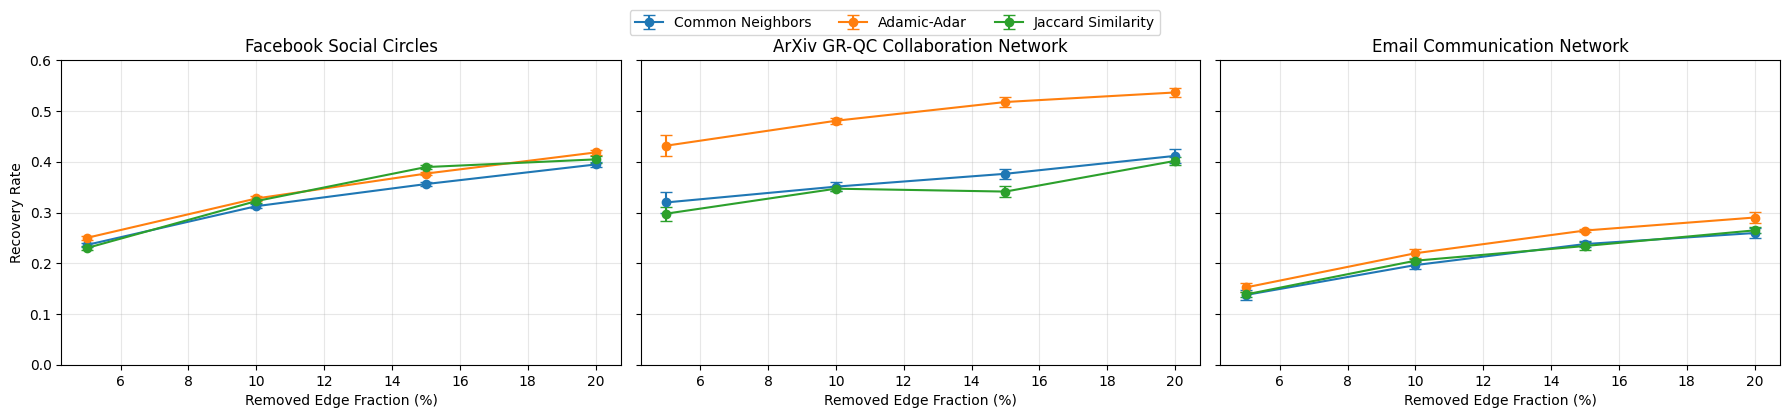

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

dataset_names = [
    "Facebook Social Circles",
    "ArXiv GR-QC Collaboration Network",
    "Email Communication Network"
]

for ax, dataset_name in zip(axes, dataset_names):
    df = summary_table[summary_table["dataset"] == dataset_name].copy()
    df = df.sort_values("remove_fraction")

    ax.errorbar(df["remove_percent"], df["cn_mean"], yerr=df["cn_std"], marker="o", capsize=4, label="Common Neighbors")
    ax.errorbar(df["remove_percent"], df["aa_mean"], yerr=df["aa_std"], marker="o", capsize=4, label="Adamic-Adar")
    ax.errorbar(df["remove_percent"], df["jc_mean"], yerr=df["jc_std"], marker="o", capsize=4, label="Jaccard Similarity")

    ax.set_title(dataset_name)
    ax.set_xlabel("Removed Edge Fraction (%)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Recovery Rate")
axes[0].set_ylim(0, 0.7)
fig.legend(
    ["Common Neighbors", "Adamic-Adar", "Jaccard Similarity"],
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.05)
)
axes[0].set_ylim(0, 0.6)

plt.tight_layout()
plt.show()

Across all three networks, Adamic–Adar consistently achieves the highest recovery rates among the classical heuristics tested. The effect is particularly strong for the ArXiv collaboration network, where recovery exceeds 0.5 when 20% of edges are removed. Facebook shows moderate recovery rates, while the Email communication network produces substantially lower scores, reflecting weaker triadic closure in organizational communication patterns. Across datasets, recovery increases with higher removed-edge fractions, likely due to the larger set of recoverable edges and increased sparsity highlighting local structural signals.